In [89]:
import pandas as pd
from genelens.netanalyzer import GeneralNet, Targets, KeyNodesExtractor, tissue_selector
import os
import sys
from tqdm import tqdm
import networkx as nx
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
from reactome2py import content
import json
import seaborn as sns

miRTargets = Targets()

def get_genes_in_pathway(pathway_id):
    ref_entities = content.participants_reference_entities(pathway_id)
    
    genes = set()
    for entity in ref_entities:
        if "geneName" in entity and entity["geneName"]:
            genes.add(entity["geneName"][0])
    
    return sorted(genes)

# Пример использования
# pathway_id = "R-HSA-448424"  # Interleukin-4 and Interleukin-13 signaling
# genes = get_genes_in_pathway(pathway_id)

def set_distance(A, B):
    keys_A = list(A.keys())
    keys_B = list(B.keys())

    # Матрица расстояний: C[i][j] = стоимость сопоставить A[i] с B[j]
    C = np.zeros((len(keys_A), len(keys_B)))

    for i, k1 in enumerate(keys_A):
        for j, k2 in enumerate(keys_B):
            if k1 == k2:
                C[i][j] = np.abs(A[k1] - B[k2])
            else:
                C[i][j] = A[k1] + B[k2]       # иначе полная цена замены

    row_ind, col_ind = linear_sum_assignment(C)

    # вывод сопоставлений
    #for i, j in zip(row_ind, col_ind):
    #    print(f"{keys_A[i]} ↔ {keys_B[j]}, cost = {C[i][j]:.2f}")

    # Общая стоимость
    total_cost = C[row_ind, col_ind].sum()
    return total_cost

def get_weighted_G(target_nodes, tissue_gene):
    G = GeneralNet(verbose=False)
    G.select_nodes(target_nodes)
    G.select_nodes(tissue_gene)
    G.get_LCC(verbose=False)
    G_weight = G.get_LCCnd_centrality()
    if not G_weight:
        return dict()
    # нормализация к максимальному значению
    max_value = max(G_weight.values())
    if max_value == 0:
        normalized_values = {k: 0 for k in G_weight}
    else:
        normalized_values = {k: v / max_value for k, v in G_weight.items()}
    return normalized_values

# настройки рисования
hist_param = {'bins': 20, 
              'color': '#FF7F50', 
              'edgecolor': 'black', 
              'alpha': 0.85}
title_param = {'fontsize': 12,
               'fontweight': 'bold'}
label_param = {'fontsize': 10}
ticks_param = {'axis': 'both', 
               'labelsize': 9}
sns.set_style("whitegrid")
FIG_DIST = 'paper/Figs/'

path_to_miRTarBase not specified. miRTarbase built-in version loaded


In [8]:
a = dict()
if a:
    print(1)

In [2]:
path_ids = ['R-HSA-202127', 
           'R-HSA-1234174.5', 
           'R-HSA-194138.4', 
           'R-HSA-190236.4', 
           'R-HSA-186797.6', 
           'R-HSA-2404192.5', 
           'R-HSA-451927.7', 
           'R-HSA-75893.10']

In [10]:
result = dict()
heart_genes = tissue_selector(ans=0, tissue_id=23)

for path in path_ids:
    kegg_G = get_weighted_G(get_genes_in_pathway(path), heart_genes)
    print(f'{path}, найдено {len(kegg_G)} генов')
    result[path] = dict()
    for miR in tqdm(miRTargets.miR_dict.keys(), desc='miRNA: '):
        miR_genes = miRTargets.get_targets(miR, verbose=False)
        miR_G = get_weighted_G(miR_genes, heart_genes)
        result[path][miR] = set_distance(kegg_G, miR_G)

with open('pathway_miR_dict_norm.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=4)

Gene universe is...
heart muscle was used
your tissue is  heart muscle  number of genes:  7944
R-HSA-202127, найдено 1 генов


miRNA:  13%|█▎        | 344/2599 [01:41<11:34,  3.25it/s]

miRNA:  15%|█▌        | 395/2599 [01:56<10:44,  3.42it/s]

miRNA:  91%|█████████▏| 2378/2599 [11:49<01:03,  3.46it/s]

miRNA:  92%|█████████▏| 2381/2599 [11:50<01:02,  3.47it/s]

...

miRNA:  92%|█████████▏| 2381/2599 [10:58<01:05,  3.31it/s]

miRNA:  98%|█████████▊| 2545/2599 [11:46<00:15,  3.50it/s]

miRNA:  99%|█████████▉| 2585/2599 [11:57<00:04,  3.28it/s]

miRNA: 100%|█████████▉| 2594/2599 [11:59<00:01,  3.70it/s]

miRNA: 100%|██████████| 2599/2599 [12:01<00:00,  3.60it/s]


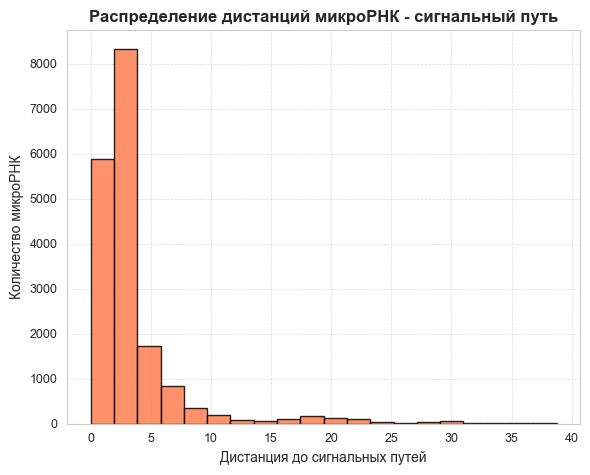

In [ ]:
global_dist = []
for path in result.keys():
    if path == 'R-HSA-202127':
        continue
    count = 0
#    print(path)
    for miR, w in result[path].items():
        global_dist.append(w)
        if 1 > w > 0:
#            print(miR, w, len(miRTargets.get_targets(miR, verbose=False)))
            count+=1
#    print(count)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))  # 4 строки, 2 столбца
ax.hist(global_dist, **hist_param)
ax.set_title('Распределение дистанций микроРНК - сигнальный путь', **title_param)
ax.set_xlabel('Дистанция до сигнальных путей', **label_param)
ax.set_ylabel('Количество микроРНК', **label_param)
ax.tick_params(**ticks_param)
#ax.set_ylim(top=max(counts) * 1.25)  # Чтобы надписи влезли
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIST+"Figure1.tiff", dpi=300, format='tiff')  # <-- Сохранение
plt.show()

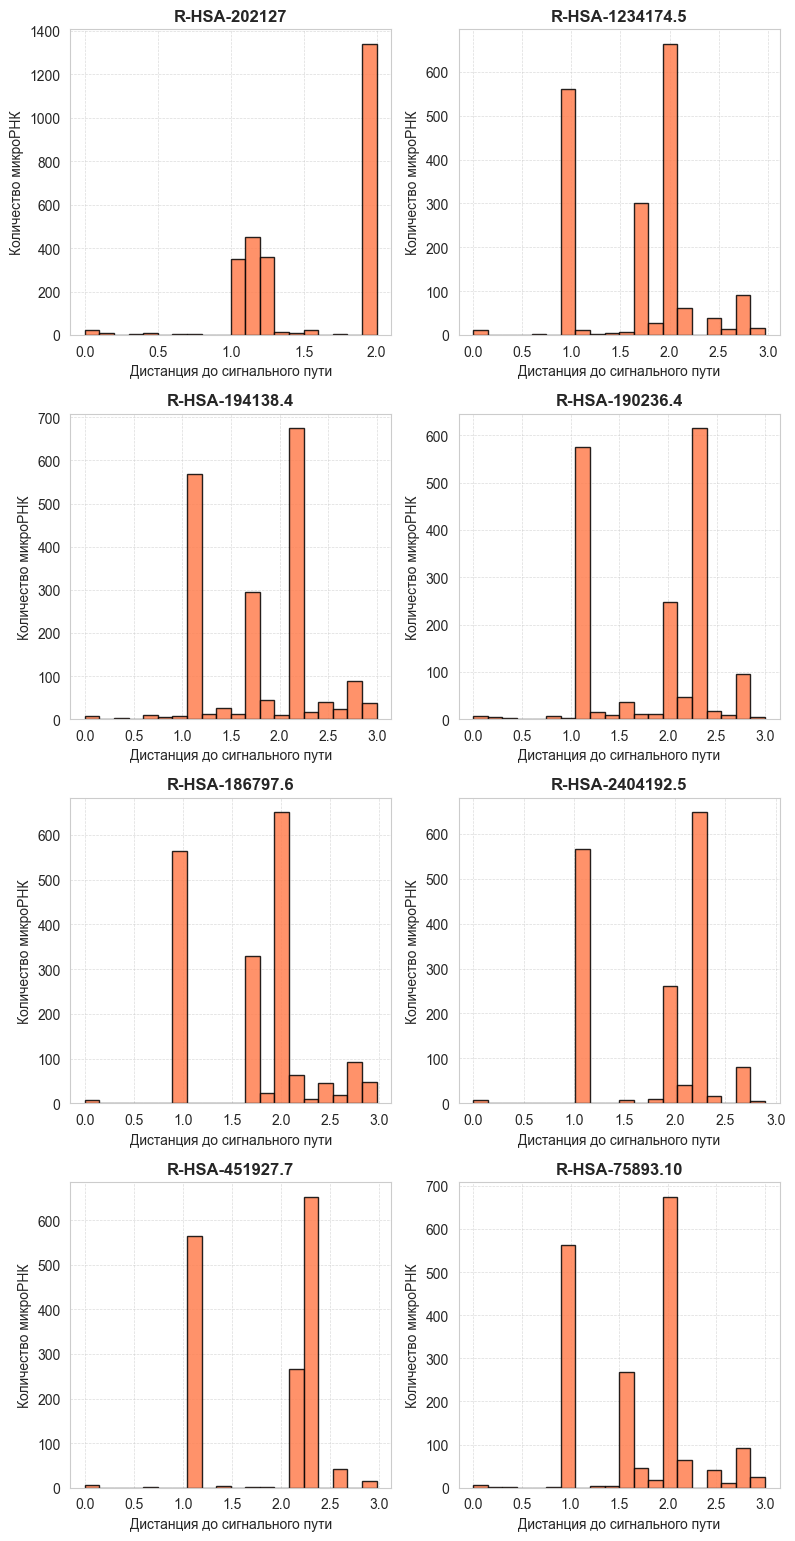

In [92]:
# Настройка фигуры
fig, axes = plt.subplots(4, 2, figsize=(8, 16))  # 4 строки, 2 столбца
axes = axes.flatten()

# Построение графиков
for i, (group, values) in enumerate(result.items()):
    ax = axes[i]

    # Фильтрация: оставляем только значения < 3
    filtered_values = [v for v in values.values() if v < 3]

    ax.hist(filtered_values, **hist_param)  # можно настроить bins
    ax.set_title(group, **title_param)
    ax.set_xlabel('Дистанция до сигнального пути', **label_param)
    ax.set_ylabel('Количество микроРНК', **label_param)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(FIG_DIST+"Figure2.tiff", dpi=300, format='tiff')  # <-- Сохранение
plt.show()


PIK3CA ↔ PIK3CA, cost = 0.00
RHOA ↔ RHOA, cost = 0.00
MAPK3 ↔ MAPK3, cost = 0.00
PAFAH1B1 ↔ MAPKAPK2, cost = 0.44
CTNNB1 ↔ MAP2K5, cost = 0.38
MYC ↔ HDAC2, cost = 0.39
PRKCA ↔ PRKCA, cost = 0.00
ERBB2 ↔ ADAM17, cost = 0.31
CDC42 ↔ APH1A, cost = 0.30
YWHAZ ↔ ARHGEF9, cost = 0.29
MAPKAP1 ↔ MAPKAP1, cost = 0.00
DEPTOR ↔ CASP9, cost = 0.18
CHPT1 ↔ TIAM1, cost = 0.15
TFRC ↔ MYD88, cost = 0.16
JAK2 ↔ NGEF, cost = 0.11
IFIT1 ↔ PSENEN, cost = 0.09
RPGRIP1L ↔ FGD2, cost = 0.09
BCL2L11 ↔ BCL2L11, cost = 0.00
RAB10 ↔ ARHGEF4, cost = 0.09
CUL5 ↔ FGD4, cost = 0.09
UGCG ↔ KALRN, cost = 0.09
NUMB ↔ ATF1, cost = 0.09
FZD4 ↔ OBSCN, cost = 0.09
IGF1R ↔ SOS2, cost = 0.09
ARHGDIA ↔ ARHGDIA, cost = 0.00
PAFAH2 ↔ HDAC1, cost = 0.08
EFNB2 ↔ SHC3, cost = 0.09
LPCAT1 ↔ GSK3A, cost = 0.09
LRP5 ↔ MEF2A, cost = 0.11
ARHGAP11A ↔ RASGRF1, cost = 0.07
ENAH ↔ RALA, cost = 0.10
SP1 ↔ ABR, cost = 0.06
TNS1 ↔ RASGRF2, cost = 0.07
RRAGC ↔ NET1, cost = 0.06
RRAGB ↔ ARHGEF11, cost = 0.07
PTPN12 ↔ HDAC3, cost = 0.07
EIF2S1 